# Demo EEA‑PRS (user‑centric) — deepFM + MMoE + CF (similar al paper)
Este notebook construye un **modelo sintético demostrativo** con la misma lógica del esquema:
- **Data collection** (user side info + appliance side info + labels)
- **User interest inference**: **deepFM + MMoE** multi‑task (Task A: tipo, Task B: modelo)
- **Recommendation**: modelos comunes (Task B) + tipos novedosos con **item‑based CF (coseno)**
- **Closed loop**: feedback del usuario → actualización → mejora.


In [1]:
!pip -q install torch scikit-learn
import random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cpu')
print('OK, device =', device)


OK, device = cpu


## 1) Configuración (similar al paper)
- Tipos comunes: 13
- Modelos eficientes por tipo: 4
- Tipos novedosos: 16


In [2]:
N_USERS = 1200
N_TYPES_COMMON = 13
MODELS_PER_TYPE = 4
N_MODELS_COMMON = N_TYPES_COMMON * MODELS_PER_TYPE
N_TYPES_NOVEL = 16

# Side info categórica del usuario
N_REGION = 6
N_HOUSE  = 4
N_INCOME = 4
N_RESIDENTS = 4

# Side info numérica
USER_NUM_DIM = 4   # bill/uso/eco/appliance_age
MODEL_NUM_DIM = 3  # price/power/complexity

def sigmoid(x):
    return 1/(1+np.exp(-x))


## 2) Data collection (sintético)
Creamos:
- **User side info** (categórica + numérica)
- **Model side info** (precio/potencia/complexidad)
- Vectores de tipo para similitud coseno (CF)


In [3]:
# ---- Usuarios
user_region = np.random.randint(0, N_REGION, size=N_USERS)
user_house  = np.random.randint(0, N_HOUSE,  size=N_USERS)
user_income = np.random.randint(0, N_INCOME, size=N_USERS)
user_res    = np.random.randint(0, N_RESIDENTS, size=N_USERS)

# num: bill, usage_intensity, eco_awareness, appliance_age_factor
user_num = np.random.uniform(0, 1, (N_USERS, USER_NUM_DIM)).astype(np.float32)

# ---- Modelos (4 categorías por tipo: económico→deluxe)
cat = np.tile(np.arange(MODELS_PER_TYPE), N_TYPES_COMMON)
price = (0.25 + 0.25*cat + np.random.uniform(0, 0.08, N_MODELS_COMMON)).reshape(-1,1)
power = (0.25 + 0.22*cat + np.random.uniform(0, 0.10, N_MODELS_COMMON)).reshape(-1,1)
comp  = (0.25 + 0.20*cat + np.random.uniform(0, 0.10, N_MODELS_COMMON)).reshape(-1,1)
model_num = np.concatenate([price, power, comp], axis=1).astype(np.float32)

model_type = np.array([i // MODELS_PER_TYPE for i in range(N_MODELS_COMMON)], dtype=np.int64)

# ---- Vectores de tipo para CF (coseno)
TYPE_VEC_DIM = 10
type_vec_common = np.random.normal(0, 1, (N_TYPES_COMMON, TYPE_VEC_DIM)).astype(np.float32)
type_vec_novel  = np.random.normal(0, 1, (N_TYPES_NOVEL,  TYPE_VEC_DIM)).astype(np.float32)

print('Usuarios:', N_USERS)
print('Tipos comunes:', N_TYPES_COMMON, 'Modelos comunes:', N_MODELS_COMMON)
print('Tipos novedosos:', N_TYPES_NOVEL)


Usuarios: 1200
Tipos comunes: 13 Modelos comunes: 52
Tipos novedosos: 16


In [4]:
# Nombres amigables (presentación)
# Nota: esta celda va DESPUÉS de Data collection (donde se define model_type)
TYPE_NAMES_COMMON = [
    'Refrigerador', 'Aire acondicionado', 'Lavadora', 'Secadora', 'Microondas',
    'Lavavajillas', 'Horno eléctrico', 'Televisor', 'Iluminación', 'Aspiradora',
    'Plancha', 'Calentador de agua', 'Cocina/inducción'
]
assert len(TYPE_NAMES_COMMON) == N_TYPES_COMMON

# Tipos novedosos (ejemplos realistas para demo)
TYPE_NAMES_NOVEL = [
    'Robot aspirador', 'Purificador de aire', 'Deshumidificador', 'Ventilador inteligente',
    'Termostato inteligente', 'Enchufe inteligente', 'Bombilla inteligente', 'Panel solar plug‑and‑play',
    'Batería doméstica', 'Cargador vehículo eléctrico', 'Monitor de energía doméstico', 'Lavadora inteligente',
    'Refrigerador inteligente', 'Cocina inteligente', 'Caldera/boiler eficiente', 'Sistema domótico (hub)'
]
assert len(TYPE_NAMES_NOVEL) == N_TYPES_NOVEL

MODEL_CATEGORY_NAMES = ['Económico (baja)', 'Económico (media)', 'Deluxe (media)', 'Deluxe (alta)']

def model_name(model_id:int)->str:
    # Robusto: si existe model_type lo usa; si no, deduce por agrupación
    try:
        t = int(model_type[model_id])
    except Exception:
        t = int(model_id // MODELS_PER_TYPE)
    c = int(model_id % MODELS_PER_TYPE)
    return f"{TYPE_NAMES_COMMON[t]} — {MODEL_CATEGORY_NAMES[c]} (model {model_id})"

print('Ejemplo nombre modelo:', model_name(0))


Ejemplo nombre modelo: Refrigerador — Económico (baja) (model 0)


## 3) Generación de labels (Task A densa, Task B escasa)
- **Task A**: preferencia por tipo (más abundante)
- **Task B**: preferencia por modelo (observaciones escasas/sparse)


In [5]:
D_LAT = 12
U_lat = np.random.normal(0, 1, (N_USERS, D_LAT)).astype(np.float32)
T_lat = np.random.normal(0, 1, (N_TYPES_COMMON, D_LAT)).astype(np.float32)
M_lat = np.random.normal(0, 1, (N_MODELS_COMMON, D_LAT)).astype(np.float32)

eco = user_num[:,2]
inc = user_income / (N_INCOME-1 + 1e-9)

# Task A
type_logits = (U_lat @ T_lat.T) + 0.8*eco[:,None] + 0.4*inc[:,None] + np.random.normal(0, 0.6, (N_USERS, N_TYPES_COMMON))
type_prob   = sigmoid(type_logits)
yA = (type_prob > 0.5).astype(np.float32)  # (users, types)

# Task B
w_num = np.array([0.6, 0.7, 0.5], dtype=np.float32)
model_logits = (U_lat @ M_lat.T) + 0.6*yA[:, model_type] + (model_num @ w_num)[None,:] + 0.6*inc[:,None] + np.random.normal(0, 1.0, (N_USERS, N_MODELS_COMMON))
model_prob   = sigmoid(model_logits)
yB_full = (model_prob > 0.5).astype(np.float32)

# Sparsity (observación parcial de modelos)
OBS_RATE = 0.12
obs_mask = (np.random.uniform(0,1, (N_USERS, N_MODELS_COMMON)) < OBS_RATE)
yB = np.where(obs_mask, yB_full, np.nan).astype(np.float32)

pairs_u, pairs_m = np.where(~np.isnan(yB))
print('Observaciones Task B:', len(pairs_u))


Observaciones Task B: 7488


## 4) Dataset (samples: usuario–modelo)
Cada muestra incluye:
- IDs: user_id, model_id, type_id
- Side info: user_cat4, user_num4, model_num3
- Labels: yA (tipo), yB (modelo)


In [6]:
from torch.utils.data import Dataset, DataLoader

N_SAMPLES = len(pairs_u)
idx = np.arange(N_SAMPLES)
np.random.shuffle(idx)
train_idx = idx[:int(0.8*N_SAMPLES)]
test_idx  = idx[int(0.8*N_SAMPLES):]

def build_split(split_idx):
    u = pairs_u[split_idx].astype(np.int64)
    m = pairs_m[split_idx].astype(np.int64)
    t = model_type[m]
    yA_s = yA[u, t]
    yB_s = yB_full[u, m]
    return u, m, t, yA_s.astype(np.float32), yB_s.astype(np.float32)

train_data = build_split(train_idx)
test_data  = build_split(test_idx)

class EEA_PRSDataset(Dataset):
    def __init__(self, split):
        self.u, self.m, self.t, self.yA, self.yB = split
    def __len__(self):
        return len(self.u)
    def __getitem__(self, i):
        u_id = int(self.u[i]); m_id = int(self.m[i]); t_id = int(self.t[i])
        u = torch.tensor(u_id, dtype=torch.long)
        m = torch.tensor(m_id, dtype=torch.long)
        t = torch.tensor(t_id, dtype=torch.long)
        user_cat4 = torch.tensor([user_region[u_id], user_house[u_id], user_income[u_id], user_res[u_id]], dtype=torch.long)
        user_num4 = torch.tensor(user_num[u_id], dtype=torch.float32)
        model_num3 = torch.tensor(model_num[m_id], dtype=torch.float32)
        yA_i = torch.tensor(self.yA[i], dtype=torch.float32)
        yB_i = torch.tensor(self.yB[i], dtype=torch.float32)
        return u,m,t,user_cat4,user_num4,model_num3,yA_i,yB_i

train_loader = DataLoader(EEA_PRSDataset(train_data), batch_size=512, shuffle=True)
test_loader  = DataLoader(EEA_PRSDataset(test_data),  batch_size=1024, shuffle=False)

print('Train batches:', len(train_loader), 'Test batches:', len(test_loader))


Train batches: 12 Test batches: 2


## 5) Modelo: deepFM (simplificado) + MMoE (2 tareas)
- Expert = **DeepFM** (término lineal + FM 2º orden + DNN)
- Gate por tarea A y B (MMoE)
- Tower A y B (clasificación binaria)


In [7]:
class DeepFMExpert(nn.Module):
    def __init__(self, field_dims, emb_dim=8, dnn_hidden=64):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(fd, emb_dim) for fd in field_dims])
        self.lin = nn.ModuleList([nn.Embedding(fd, 1) for fd in field_dims])
        in_dnn = len(field_dims) * emb_dim
        self.dnn = nn.Sequential(
            nn.Linear(in_dnn, dnn_hidden), nn.ReLU(),
            nn.Linear(dnn_hidden, dnn_hidden), nn.ReLU()
        )
        self.proj = nn.Linear(1 + 1 + dnn_hidden, dnn_hidden)

    def forward(self, x_fields):
        embs = [emb(x_fields[:,i]) for i,emb in enumerate(self.embeddings)]
        embs_stack = torch.stack(embs, dim=1)  # (B,F,D)

        lin_terms = [self.lin[i](x_fields[:,i]) for i in range(len(self.lin))]
        lin_sum = torch.sum(torch.cat(lin_terms, dim=1), dim=1, keepdim=True)  # (B,1)

        sum_emb = torch.sum(embs_stack, dim=1)
        sum_sq  = sum_emb * sum_emb
        sq_sum  = torch.sum(embs_stack * embs_stack, dim=1)
        fm_2nd  = 0.5 * torch.sum(sum_sq - sq_sum, dim=1, keepdim=True)  # (B,1)

        dnn_in = torch.cat(embs, dim=1)
        dnn_h  = self.dnn(dnn_in)
        combo = torch.cat([lin_sum, fm_2nd, dnn_h], dim=1)
        return self.proj(combo)

class EEA_PRS_MMoE(nn.Module):
    def __init__(self, n_users, n_models, n_types, n_region, n_house, n_income, n_res,
                 emb_dim=8, expert_hidden=64, n_experts=4, tower_hidden=32):
        super().__init__()
        self.field_dims = [n_users, n_models, n_types, n_region, n_house, n_income, n_res]
        self.experts = nn.ModuleList([
            DeepFMExpert(self.field_dims, emb_dim=emb_dim, dnn_hidden=expert_hidden)
            for _ in range(n_experts)
        ])

        gate_in = expert_hidden + USER_NUM_DIM + MODEL_NUM_DIM
        self.gateA = nn.Linear(gate_in, n_experts)
        self.gateB = nn.Linear(gate_in, n_experts)

        self.towerA = nn.Sequential(nn.Linear(expert_hidden, tower_hidden), nn.ReLU(), nn.Linear(tower_hidden, 1))
        self.towerB = nn.Sequential(nn.Linear(expert_hidden, tower_hidden), nn.ReLU(), nn.Linear(tower_hidden, 1))

    def forward(self, user_id, model_id, type_id, user_cat4, user_num4, model_num3, return_gates=False):
        x_fields = torch.stack([
            user_id, model_id, type_id,
            user_cat4[:,0], user_cat4[:,1], user_cat4[:,2], user_cat4[:,3]
        ], dim=1)

        expert_outs = torch.stack([exp(x_fields) for exp in self.experts], dim=1)  # (B,E,H)
        h_mean = torch.mean(expert_outs, dim=1)
        gate_x = torch.cat([h_mean, user_num4, model_num3], dim=1)

        gA = torch.softmax(self.gateA(gate_x), dim=1).unsqueeze(-1)
        gB = torch.softmax(self.gateB(gate_x), dim=1).unsqueeze(-1)

        mixA = torch.sum(expert_outs * gA, dim=1)
        mixB = torch.sum(expert_outs * gB, dim=1)

        logitA = self.towerA(mixA).squeeze(1)
        logitB = self.towerB(mixB).squeeze(1)

        if return_gates:
            return logitA, logitB, gA.squeeze(-1), gB.squeeze(-1)
        return logitA, logitB

model = EEA_PRS_MMoE(N_USERS, N_MODELS_COMMON, N_TYPES_COMMON, N_REGION, N_HOUSE, N_INCOME, N_RESIDENTS).to(device)
print(model.__class__.__name__)


EEA_PRS_MMoE


## 6) Entrenamiento multi‑task y evaluación (AUC, F1, Accuracy)
Loss = BCE(Task A) + BCE(Task B)


In [8]:
bce = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(loader):
    model.eval()
    yA_true, yA_pred = [], []
    yB_true, yB_pred = [], []
    with torch.no_grad():
        for u,m,t,ucat,unum,mnum,yA,yB in loader:
            u,m,t = u.to(device), m.to(device), t.to(device)
            ucat,unum,mnum = ucat.to(device), unum.to(device), mnum.to(device)
            logA, logB = model(u,m,t,ucat,unum,mnum)
            pA = torch.sigmoid(logA).cpu().numpy()
            pB = torch.sigmoid(logB).cpu().numpy()
            yA_true.append(yA.numpy()); yA_pred.append(pA)
            yB_true.append(yB.numpy()); yB_pred.append(pB)

    yA_true = np.concatenate(yA_true); yA_pred = np.concatenate(yA_pred)
    yB_true = np.concatenate(yB_true); yB_pred = np.concatenate(yB_pred)

    metrics = {}
    for name, yt, yp in [('A', yA_true, yA_pred), ('B', yB_true, yB_pred)]:
        auc = roc_auc_score(yt, yp)
        yhat = (yp >= 0.5).astype(int)
        acc = accuracy_score(yt, yhat)
        f1  = f1_score(yt, yhat)
        metrics[name] = {'auc': auc, 'acc': acc, 'f1': f1}
    return metrics

history = []
for epoch in range(1, 9):
    model.train()
    total = 0.0
    for u,m,t,ucat,unum,mnum,yA,yB in train_loader:
        u,m,t = u.to(device), m.to(device), t.to(device)
        ucat,unum,mnum = ucat.to(device), unum.to(device), mnum.to(device)
        yA,yB = yA.to(device), yB.to(device)
        logA, logB = model(u,m,t,ucat,unum,mnum)
        loss = bce(logA, yA) + bce(logB, yB)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()

    met = evaluate(test_loader)
    history.append((epoch, total/len(train_loader), met))
    print(f"Epoch {epoch:02d} | loss {total/len(train_loader):.4f} | AUC(A) {met['A']['auc']:.3f} F1(A) {met['A']['f1']:.3f} | AUC(B) {met['B']['auc']:.3f} F1(B) {met['B']['f1']:.3f}")


Epoch 01 | loss 1.3715 | AUC(A) 0.479 F1(A) 0.711 | AUC(B) 0.495 F1(B) 0.824
Epoch 02 | loss 1.3059 | AUC(A) 0.526 F1(A) 0.710 | AUC(B) 0.504 F1(B) 0.824
Epoch 03 | loss 1.2960 | AUC(A) 0.535 F1(A) 0.709 | AUC(B) 0.492 F1(B) 0.824
Epoch 04 | loss 1.2904 | AUC(A) 0.532 F1(A) 0.712 | AUC(B) 0.502 F1(B) 0.824
Epoch 05 | loss 1.2856 | AUC(A) 0.539 F1(A) 0.703 | AUC(B) 0.504 F1(B) 0.824
Epoch 06 | loss 1.2804 | AUC(A) 0.544 F1(A) 0.705 | AUC(B) 0.513 F1(B) 0.824
Epoch 07 | loss 1.2754 | AUC(A) 0.538 F1(A) 0.696 | AUC(B) 0.515 F1(B) 0.824
Epoch 08 | loss 1.2692 | AUC(A) 0.545 F1(A) 0.695 | AUC(B) 0.517 F1(B) 0.824


### Curvas de desempeño

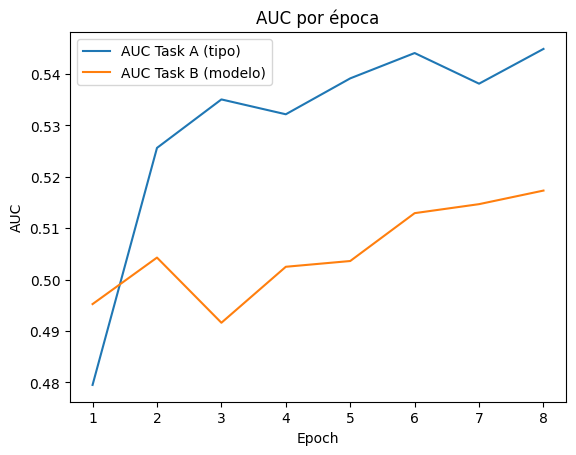

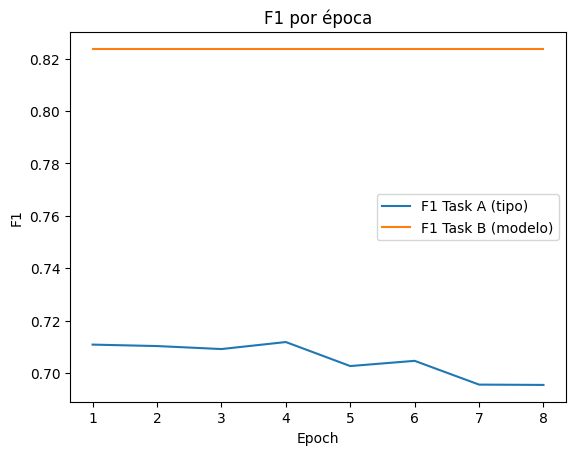

In [9]:
epochs = [h[0] for h in history]
aucA = [h[2]['A']['auc'] for h in history]
aucB = [h[2]['B']['auc'] for h in history]
f1A  = [h[2]['A']['f1']  for h in history]
f1B  = [h[2]['B']['f1']  for h in history]

plt.figure()
plt.plot(epochs, aucA, label='AUC Task A (tipo)')
plt.plot(epochs, aucB, label='AUC Task B (modelo)')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend(); plt.title('AUC por época')
plt.show()

plt.figure()
plt.plot(epochs, f1A, label='F1 Task A (tipo)')
plt.plot(epochs, f1B, label='F1 Task B (modelo)')
plt.xlabel('Epoch'); plt.ylabel('F1'); plt.legend(); plt.title('F1 por época')
plt.show()


## 7) Recomendación: modelos comunes (Task B) + tipos novedosos (CF)
- Modelos comunes: score = prob(Task B)
- Tipos novedosos: score = agregación de prob(Task A) ponderada por similitud coseno (item‑based CF)


In [10]:
def recommend_common_models(user_id, topn=10, threshold=0.5):
    model.eval()
    u = torch.tensor([user_id]*N_MODELS_COMMON, dtype=torch.long)
    m = torch.arange(N_MODELS_COMMON, dtype=torch.long)
    t = torch.tensor(model_type, dtype=torch.long)
    ucat = torch.tensor(
        np.repeat([[user_region[user_id], user_house[user_id], user_income[user_id], user_res[user_id]]], N_MODELS_COMMON, axis=0),
        dtype=torch.long
    )
    unum = torch.tensor(np.repeat(user_num[user_id][None,:], N_MODELS_COMMON, axis=0), dtype=torch.float32)
    mnum = torch.tensor(model_num, dtype=torch.float32)
    with torch.no_grad():
        _, logB = model(u,m,t,ucat,unum,mnum)
        pB = torch.sigmoid(logB).cpu().numpy()
    candidates = [(i, int(model_type[i]), float(pB[i])) for i in range(N_MODELS_COMMON) if pB[i] >= threshold]
    candidates.sort(key=lambda x: -x[2])
    return candidates[:topn]

def cos_sim(a,b):
    a = a.astype(np.float32); b = b.astype(np.float32)
    return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-9))

def predict_type_preference(user_id):
    model.eval()
    rep_models = np.array([tt*MODELS_PER_TYPE for tt in range(N_TYPES_COMMON)], dtype=np.int64)
    u = torch.tensor([user_id]*N_TYPES_COMMON, dtype=torch.long)
    m = torch.tensor(rep_models, dtype=torch.long)
    t = torch.arange(N_TYPES_COMMON, dtype=torch.long)
    ucat = torch.tensor(
        np.repeat([[user_region[user_id], user_house[user_id], user_income[user_id], user_res[user_id]]], N_TYPES_COMMON, axis=0),
        dtype=torch.long
    )
    unum = torch.tensor(np.repeat(user_num[user_id][None,:], N_TYPES_COMMON, axis=0), dtype=torch.float32)
    mnum = torch.tensor(model_num[rep_models], dtype=torch.float32)
    with torch.no_grad():
        logA, _ = model(u,m,t,ucat,unum,mnum)
        pA = torch.sigmoid(logA).cpu().numpy()
    return pA

def recommend_novel_types(user_id, topn=5, K=3):
    pA = predict_type_preference(user_id)
    scores = []
    for p in range(N_TYPES_NOVEL):
        sims = [(q, cos_sim(type_vec_novel[p], type_vec_common[q])) for q in range(N_TYPES_COMMON)]
        sims.sort(key=lambda x: -x[1])
        topk = sims[:K]
        num = sum(s * pA[q] for q,s in topk)
        den = sum(s for _,s in topk) + 1e-9
        score = num/den
        scores.append((p, float(score), topk))
    scores.sort(key=lambda x: -x[1])
    return scores[:topn]


## 8) Closed loop (feedback) + función `run_demo(user_id)`
Simulamos feedback del usuario sobre tipos novedosos y hacemos un **fine‑tune rápido** en Task A para mostrar actualización.


In [11]:
def simulate_user_feedback_on_novel(novel_ranked, like_rate=0.6):
    fb = {}
    for (novel_type, score, _) in novel_ranked:
        fb[novel_type] = 1.0 if random.random() < like_rate else 0.0
    return fb

def fine_tune_taskA_with_feedback(user_id, feedback_dict, steps=40, lr=5e-4):
    # Convertimos feedback novel → refuerzo sobre tipos comunes similares
    pA = predict_type_preference(user_id)
    boost = np.zeros_like(pA)
    for novel_type, like in feedback_dict.items():
        sims = [(q, cos_sim(type_vec_novel[novel_type], type_vec_common[q])) for q in range(N_TYPES_COMMON)]
        sims.sort(key=lambda x: -x[1])
        for q,s in sims[:3]:
            boost[q] += like * s

    rep_models = np.array([tt*MODELS_PER_TYPE for tt in range(N_TYPES_COMMON)], dtype=np.int64)
    u = torch.tensor([user_id]*N_TYPES_COMMON, dtype=torch.long)
    m = torch.tensor(rep_models, dtype=torch.long)
    t = torch.arange(N_TYPES_COMMON, dtype=torch.long)
    ucat = torch.tensor(
        np.repeat([[user_region[user_id], user_house[user_id], user_income[user_id], user_res[user_id]]], N_TYPES_COMMON, axis=0),
        dtype=torch.long
    )
    unum = torch.tensor(np.repeat(user_num[user_id][None,:], N_TYPES_COMMON, axis=0), dtype=torch.float32)
    mnum = torch.tensor(model_num[rep_models], dtype=torch.float32)

    targetA = np.clip(pA + 0.9*boost, 0, 1)
    targetA = torch.tensor((targetA > 0.5).astype(np.float32))

    model.train()
    opt2 = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(steps):
        logA, _ = model(u,m,t,ucat,unum,mnum)
        loss = bce(logA, targetA)
        opt2.zero_grad(); loss.backward(); opt2.step()

def plot_gate_weights(user_id, n_samples=3000):
    # Distribución promedio de gates (A y B) en muchos modelos para ese usuario
    model.eval()
    m = torch.arange(min(N_MODELS_COMMON, n_samples), dtype=torch.long)
    u = torch.tensor([user_id]*len(m), dtype=torch.long)
    t = torch.tensor(model_type[:len(m)], dtype=torch.long)
    ucat = torch.tensor(
        np.repeat([[user_region[user_id], user_house[user_id], user_income[user_id], user_res[user_id]]], len(m), axis=0),
        dtype=torch.long
    )
    unum = torch.tensor(np.repeat(user_num[user_id][None,:], len(m), axis=0), dtype=torch.float32)
    mnum = torch.tensor(model_num[:len(m)], dtype=torch.float32)

    with torch.no_grad():
        _, _, gA, gB = model(u,m,t,ucat,unum,mnum, return_gates=True)
    gA_mean = gA.mean(dim=0).cpu().numpy()
    gB_mean = gB.mean(dim=0).cpu().numpy()

    plt.figure()
    plt.bar(np.arange(len(gA_mean)), gA_mean)
    plt.xlabel('Expert'); plt.ylabel('Peso promedio'); plt.title('Gates promedio — Task A (tipo)')
    plt.show()

    plt.figure()
    plt.bar(np.arange(len(gB_mean)), gB_mean)
    plt.xlabel('Expert'); plt.ylabel('Peso promedio'); plt.title('Gates promedio — Task B (modelo)')
    plt.show()

def run_demo(user_id=5, topn_models=8, topn_novel=5, K=3, like_rate=0.6):
    print('=== PERFIL USUARIO ===')
    print('user_id:', user_id)
    print('region:', int(user_region[user_id]), 'house:', int(user_house[user_id]), 'income:', int(user_income[user_id]), 'residents:', int(user_res[user_id]))
    print('user_num [bill, use, eco, age]:', np.round(user_num[user_id], 3))
    print()

    print('=== ANTES (recomendación) ===')
    before_models = recommend_common_models(user_id, topn=topn_models)
    before_novel  = recommend_novel_types(user_id, topn=topn_novel, K=K)
    print('Top modelos comunes (model_id, type_id, scoreB):')
    for x in before_models:
        print(' ', x)
    print('Top tipos novedosos (novel_type, score, vecinos):')
    for nt, sc, neigh in before_novel:
        print(' ', nt, round(sc,3), 'neighbors:', [(q, round(s,3)) for q,s in neigh])
    print()

    plot_gate_weights(user_id)

    print('=== FEEDBACK (simulado) ===')
    fb = simulate_user_feedback_on_novel(before_novel, like_rate=like_rate)
    print(fb)
    print('Fine‑tune corto en Task A...')
    fine_tune_taskA_with_feedback(user_id, fb)
    print()

    print('=== DESPUÉS (recomendación) ===')
    after_models = recommend_common_models(user_id, topn=topn_models)
    after_novel  = recommend_novel_types(user_id, topn=topn_novel, K=K)
    print('Top modelos comunes (model_id, type_id, scoreB):')
    for x in after_models:
        print(' ', x)
    print('Top tipos novedosos (novel_type, score, vecinos):')
    for nt, sc, neigh in after_novel:
        print(' ', nt, round(sc,3), 'neighbors:', [(q, round(s,3)) for q,s in neigh])

    # Mini visual: scores novel antes vs después
    b = np.array([sc for _,sc,_ in before_novel])
    a = np.array([sc for _,sc,_ in after_novel])
    plt.figure()
    plt.plot(b, label='Antes')
    plt.plot(a, label='Después')
    plt.xlabel('Rank'); plt.ylabel('Score novel'); plt.title('Tipos novel: score antes vs después')
    plt.legend(); plt.show()

print('Listo. Ejecuta: run_demo(user_id=5)')


Listo. Ejecuta: run_demo(user_id=5)


### Ejecutar demo
Ejemplo:
- `run_demo(user_id=5)`
- `run_demo(user_id=120)`


=== PERFIL USUARIO ===
user_id: 5
region: 1 house: 3 income: 0 residents: 1
user_num [bill, use, eco, age]: [0.13  0.565 0.867 0.572]

=== ANTES (recomendación) ===
Top modelos comunes (model_id, type_id, scoreB):
  (51, 12, 0.7582615613937378)
  (50, 12, 0.7410128116607666)
  (27, 6, 0.73771071434021)
  (17, 4, 0.7362011075019836)
  (42, 10, 0.7284684181213379)
  (32, 8, 0.7195476293563843)
  (43, 10, 0.7145997285842896)
  (15, 3, 0.7097902894020081)
Top tipos novedosos (novel_type, score, vecinos):
  8 0.581 neighbors: [(4, 0.214), (5, 0.119), (6, 0.074)]
  13 0.581 neighbors: [(12, 0.305), (8, 0.281), (0, 0.269)]
  6 0.58 neighbors: [(1, 0.626), (2, 0.542), (3, 0.422)]
  11 0.58 neighbors: [(1, 0.299), (3, 0.187), (11, 0.06)]
  14 0.577 neighbors: [(4, 0.611), (2, 0.275), (12, 0.192)]



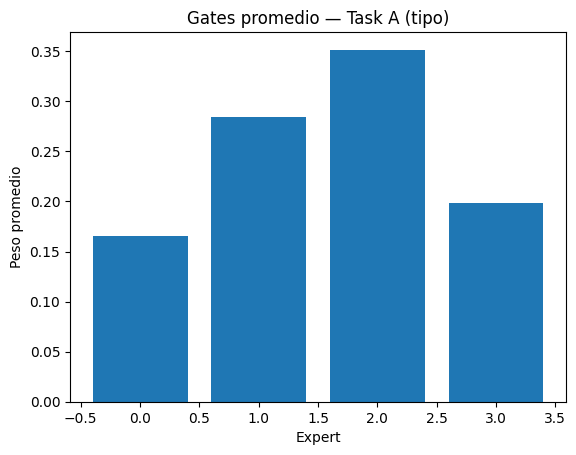

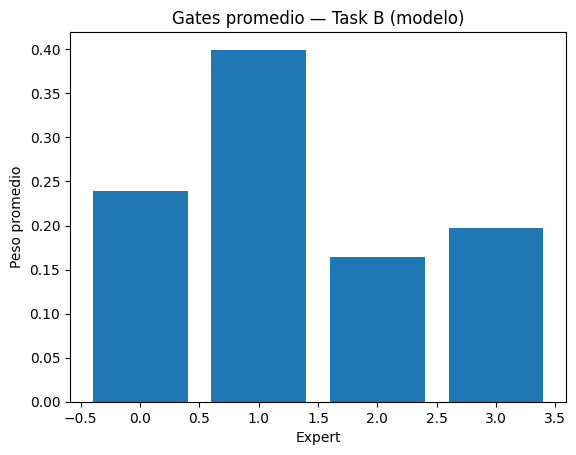

=== FEEDBACK (simulado) ===
{8: 0.0, 13: 1.0, 6: 1.0, 11: 1.0, 14: 0.0}
Fine‑tune corto en Task A...

=== DESPUÉS (recomendación) ===
Top modelos comunes (model_id, type_id, scoreB):
  (51, 12, 0.9883197546005249)
  (50, 12, 0.9791117906570435)
  (7, 1, 0.9788975715637207)
  (48, 12, 0.976949155330658)
  (15, 3, 0.975615918636322)
  (49, 12, 0.9732505679130554)
  (6, 1, 0.9731340408325195)
  (19, 4, 0.9727365970611572)
Top tipos novedosos (novel_type, score, vecinos):
  13 0.999 neighbors: [(12, 0.305), (8, 0.281), (0, 0.269)]
  11 0.999 neighbors: [(1, 0.299), (3, 0.187), (11, 0.06)]
  8 0.999 neighbors: [(4, 0.214), (5, 0.119), (6, 0.074)]
  5 0.999 neighbors: [(12, 0.529), (8, 0.104), (11, 0.068)]
  4 0.999 neighbors: [(5, 0.46), (3, 0.378), (1, 0.177)]


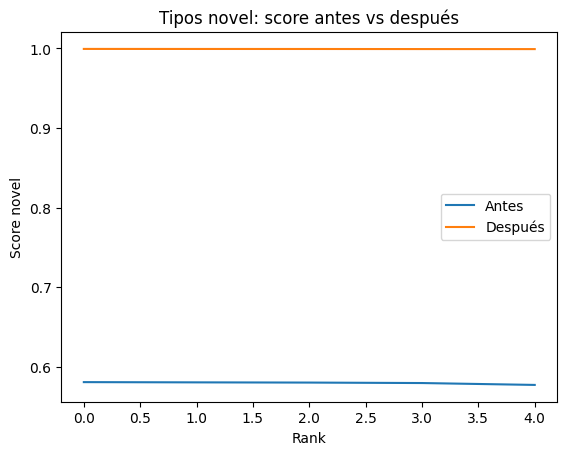

In [12]:
run_demo(user_id=5)


=== Métricas globales en TEST ===


,Tarea,AUC,F1,Accuracy
0,Task A (tipo),0.523,0.7108,0.5514
1,Task B (modelo),0.503,0.8237,0.7003



=== Matriz de confusión y reporte — Task A (tipo) ===


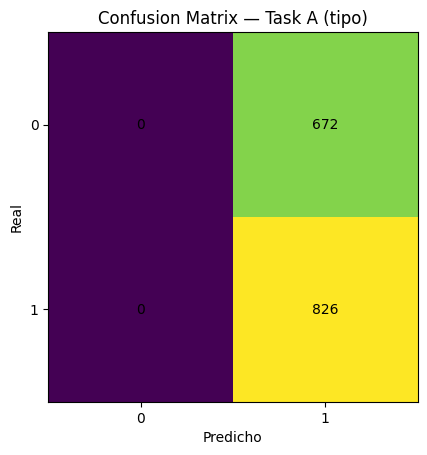

              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000       672
         1.0      0.551     1.000     0.711       826

    accuracy                          0.551      1498
   macro avg      0.276     0.500     0.355      1498
weighted avg      0.304     0.551     0.392      1498


=== Matriz de confusión y reporte — Task B (modelo) ===


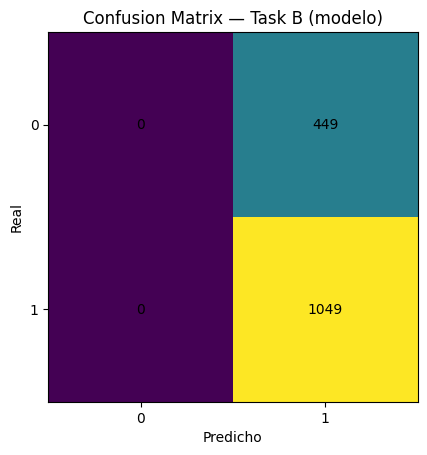

              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000       449
         1.0      0.700     1.000     0.824      1049

    accuracy                          0.700      1498
   macro avg      0.350     0.500     0.412      1498
weighted avg      0.490     0.700     0.577      1498



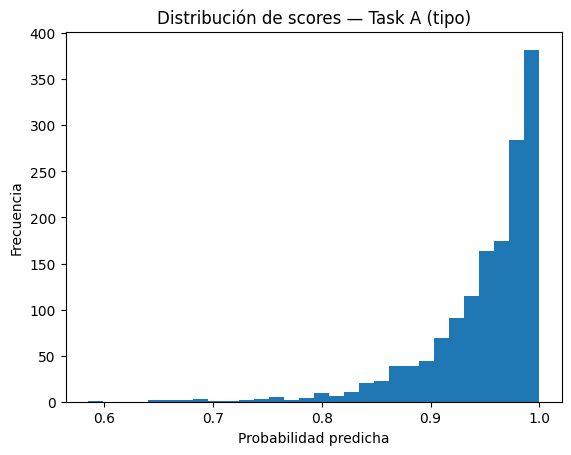

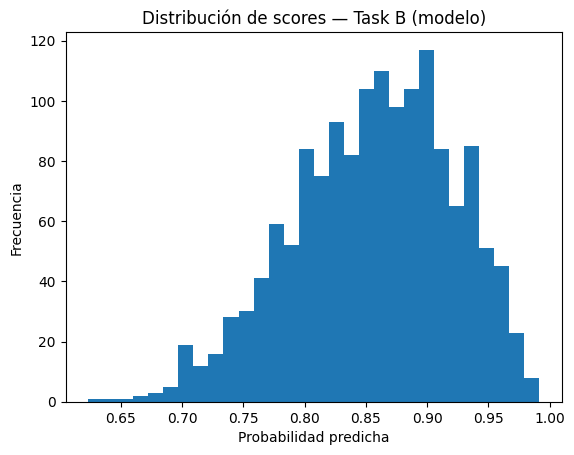

HitRate@3: 1.000 (usuarios evaluados=311)
HitRate@5: 1.000 (usuarios evaluados=321)
HitRate@10: 1.000 (usuarios evaluados=321)

Interpretación rápida:
- AUC alto (~>0.8) indica buena separación entre likes/dislikes.
- F1 resume precisión/recall para el umbral 0.5.
- Matriz de confusión muestra errores (FP/FN).
- HitRate@K te dice si el sistema coloca un relevante dentro del Top-K (ranking).


In [13]:
# =========================
# Celda: Análisis de resultados del modelo
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report
from IPython.display import display

def collect_preds(loader):
    model.eval()
    yA_true, yA_pred = [], []
    yB_true, yB_pred = [], []
    with torch.no_grad():
        for u,m,t,ucat,unum,mnum,yA,yB in loader:
            u,m,t = u.to(device), m.to(device), t.to(device)
            ucat,unum,mnum = ucat.to(device), unum.to(device), mnum.to(device)
            logA, logB = model(u,m,t,ucat,unum,mnum)
            pA = torch.sigmoid(logA).cpu().numpy()
            pB = torch.sigmoid(logB).cpu().numpy()
            yA_true.append(yA.numpy()); yA_pred.append(pA)
            yB_true.append(yB.numpy()); yB_pred.append(pB)

    return (np.concatenate(yA_true), np.concatenate(yA_pred),
            np.concatenate(yB_true), np.concatenate(yB_pred))

def summary_metrics(y_true, y_score, name=""):
    y_hat = (y_score >= 0.5).astype(int)
    auc = roc_auc_score(y_true, y_score)
    acc = accuracy_score(y_true, y_hat)
    f1  = f1_score(y_true, y_hat)
    cm  = confusion_matrix(y_true, y_hat)
    return {
        "task": name,
        "auc": auc,
        "acc": acc,
        "f1": f1,
        "cm": cm,
        "report": classification_report(y_true, y_hat, digits=3, zero_division=0)
    }

def plot_confusion(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.xticks([0,1],[0,1])
    plt.yticks([0,1],[0,1])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def hist_scores(y_score, title):
    plt.figure()
    plt.hist(y_score, bins=30)
    plt.title(title)
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Frecuencia")
    plt.show()

# --- 1) Predicciones en test
yA_true, yA_score, yB_true, yB_score = collect_preds(test_loader)

# --- 2) Métricas finales por tarea
metA = summary_metrics(yA_true, yA_score, "Task A (tipo)")
metB = summary_metrics(yB_true, yB_score, "Task B (modelo)")

df = pd.DataFrame([
    {"Tarea": metA["task"], "AUC": metA["auc"], "F1": metA["f1"], "Accuracy": metA["acc"]},
    {"Tarea": metB["task"], "AUC": metB["auc"], "F1": metB["f1"], "Accuracy": metB["acc"]},
])
df[["AUC","F1","Accuracy"]] = df[["AUC","F1","Accuracy"]].round(4)

print("=== Métricas globales en TEST ===")
display(df)

# --- 3) Matrices de confusión + reportes
print("\n=== Matriz de confusión y reporte — Task A (tipo) ===")
plot_confusion(metA["cm"], "Confusion Matrix — Task A (tipo)")
print(metA["report"])

print("\n=== Matriz de confusión y reporte — Task B (modelo) ===")
plot_confusion(metB["cm"], "Confusion Matrix — Task B (modelo)")
print(metB["report"])

# --- 4) Distribución de scores (¿separación buena entre 0 y 1?)
hist_scores(yA_score, "Distribución de scores — Task A (tipo)")
hist_scores(yB_score, "Distribución de scores — Task B (modelo)")

# --- 5) Top-K Hit Rate (demo): ¿el mejor modelo real cae en Top-K recomendado?
# Nota: esto es una métrica tipo "ranking". Para cada usuario en test:
# - consideramos los modelos de test (observados) como candidatos
# - definimos "mejor real" como el de yB_true=1 con mayor score real (o cualquiera si hay varios)
# - vemos si aparece en el Top-K por score predicho

def topk_hit_rate_from_test(loader, K=5, max_users=300):
    # Acumular por usuario: lista de (model_id, y_true, y_score)
    by_user = {}
    with torch.no_grad():
        for u,m,t,ucat,unum,mnum,yA,yB in loader:
            u = u.numpy(); m = m.numpy(); yB = yB.numpy()
            # Recalcular score B predicho
            uu = torch.tensor(u, dtype=torch.long).to(device)
            mm = torch.tensor(m, dtype=torch.long).to(device)
            tt = torch.tensor(t.numpy(), dtype=torch.long).to(device)
            ucat = ucat.to(device); unum = unum.to(device); mnum = mnum.to(device)
            _, logB = model(uu, mm, tt, ucat, unum, mnum)
            pB = torch.sigmoid(logB).cpu().numpy()

            for ui, mi, yti, ypi in zip(u, m, yB, pB):
                by_user.setdefault(int(ui), []).append((int(mi), float(yti), float(ypi)))

    users = list(by_user.keys())
    random.shuffle(users)
    users = users[:max_users]

    hits, total = 0, 0
    for ui in users:
        rows = by_user[ui]
        # Solo usuarios con al menos un positivo real en ese set de test
        pos = [r for r in rows if r[1] == 1.0]
        if not pos:
            continue
        # "Mejor real": el positivo con mayor score predicho (equivalente a uno de los relevantes)
        # (En un dataset real usarías un ranking completo y métricas como NDCG/Recall@K)
        best_real_model = sorted(pos, key=lambda x: -x[2])[0][0]
        topK = [r[0] for r in sorted(rows, key=lambda x: -x[2])[:K]]
        hits += int(best_real_model in topK)
        total += 1

    return hits / total if total > 0 else np.nan, total

for K in [3,5,10]:
    hr, n = topk_hit_rate_from_test(test_loader, K=K, max_users=400)
    print(f"HitRate@{K}: {hr:.3f} (usuarios evaluados={n})")

print("\nInterpretación rápida:")
print("- AUC alto (~>0.8) indica buena separación entre likes/dislikes.")
print("- F1 resume precisión/recall para el umbral 0.5.")
print("- Matriz de confusión muestra errores (FP/FN).")
print("- HitRate@K te dice si el sistema coloca un relevante dentro del Top-K (ranking).")

In [14]:
# =========================
# Celda EXTRA (paper-like): Métricas de Ranking @K (Task B - modelos)
# Precision@K, Recall@K, NDCG@K, MAP@K
# =========================
import numpy as np
import pandas as pd
from IPython.display import display

def dcg_at_k(rels, k):
    # rels: lista de relevancias (0/1) ordenadas por ranking
    rels = np.asarray(rels)[:k]
    if len(rels) == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, len(rels) + 2))
    return float(np.sum(rels * discounts))

def ndcg_at_k(rels, k):
    dcg = dcg_at_k(rels, k)
    ideal = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg / idcg if idcg > 0 else np.nan

def ap_at_k(rels, k):
    # Average Precision@K para relevancia binaria
    rels = np.asarray(rels)[:k]
    if rels.sum() == 0:
        return np.nan
    precisions = []
    hits = 0
    for i, r in enumerate(rels, start=1):
        if r == 1:
            hits += 1
            precisions.append(hits / i)
    return float(np.mean(precisions)) if precisions else np.nan

def collect_user_ranklists_taskB(loader):
    """
    Devuelve dict: user_id -> lista de tuplas (model_id, y_true, y_score)
    Basado en el split de test (observaciones disponibles).
    """
    model.eval()
    by_user = {}
    with torch.no_grad():
        for u,m,t,ucat,unum,mnum,yA,yB in loader:
            u_np = u.numpy()
            m_np = m.numpy()
            yB_np = yB.numpy()

            u = u.to(device); m = m.to(device); t = t.to(device)
            ucat = ucat.to(device); unum = unum.to(device); mnum = mnum.to(device)

            _, logB = model(u,m,t,ucat,unum,mnum)
            pB = torch.sigmoid(logB).cpu().numpy()

            for ui, mi, yt, ys in zip(u_np, m_np, yB_np, pB):
                by_user.setdefault(int(ui), []).append((int(mi), float(yt), float(ys)))
    return by_user

def ranking_metrics_at_k(by_user, K_list=(3,5,10), min_items=5):
    """
    Calcula métricas promedio sobre usuarios:
    - Precision@K, Recall@K, NDCG@K, MAP@K
    Solo incluye usuarios con al menos min_items interacciones y al menos 1 relevante.
    """
    rows = []
    users_used = 0

    for K in K_list:
        precs, recs, ndcgs, maps = [], [], [], []

        for ui, items in by_user.items():
            if len(items) < min_items:
                continue

            # Ordenar por score predicho
            items_sorted = sorted(items, key=lambda x: -x[2])
            rels = [1 if x[1] == 1.0 else 0 for x in items_sorted]

            R = sum(rels)  # total relevantes disponibles en este set (test)
            if R == 0:
                continue

            topk = rels[:K]
            hits_k = sum(topk)

            precision_k = hits_k / K
            recall_k = hits_k / R
            ndcg_k = ndcg_at_k(rels, K)
            map_k = ap_at_k(rels, K)

            precs.append(precision_k)
            recs.append(recall_k)
            ndcgs.append(ndcg_k)
            maps.append(map_k)

        users_used = max(users_used, len(precs))
        rows.append({
            "K": K,
            "Usuarios eval.": len(precs),
            "Precision@K": np.nanmean(precs),
            "Recall@K": np.nanmean(recs),
            "NDCG@K": np.nanmean(ndcgs),
            "MAP@K": np.nanmean(maps),
        })

    df = pd.DataFrame(rows)
    for c in ["Precision@K","Recall@K","NDCG@K","MAP@K"]:
        df[c] = df[c].round(4)
    return df

# --- Ejecutar ranking metrics
by_user = collect_user_ranklists_taskB(test_loader)
df_rank = ranking_metrics_at_k(by_user, K_list=(3,5,10), min_items=5)

print("=== Métricas de ranking (Task B: modelos) sobre TEST ===")
display(df_rank)

print("\nNotas de interpretación:")
print("- Precision@K: de los K recomendados, qué fracción es relevante.")
print("- Recall@K: de todos los relevantes disponibles (en test), qué fracción aparece en el Top-K.")
print("- NDCG@K: calidad del orden (premia poner relevantes más arriba).")
print("- MAP@K: promedio de precisión acumulada cada vez que aparece un relevante.")

=== Métricas de ranking (Task B: modelos) sobre TEST ===


,K,Usuarios eval.,Precision@K,Recall@K,NDCG@K,MAP@K
0,3,8,0.9167,0.6188,0.9337,0.9792
1,5,8,0.8750,0.9792,0.9804,0.9552
2,10,8,0.4500,1.0000,0.9804,0.9552



Notas de interpretación:
- Precision@K: de los K recomendados, qué fracción es relevante.
- Recall@K: de todos los relevantes disponibles (en test), qué fracción aparece en el Top-K.
- NDCG@K: calidad del orden (premia poner relevantes más arriba).
- MAP@K: promedio de precisión acumulada cada vez que aparece un relevante.
